In [1]:
import os
from skimage import io, color, feature, transform
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load and preprocess the dataset
data_dir = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
hog_features = []
labels = []

for folder in os.listdir(data_dir):
    label = folder
    folder_path = os.path.join(data_dir, folder)
    for image_file in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_file)
        image = io.imread(image_path)
        image = transform.resize(image, (64, 64))  # Resize to a consistent size
        image = color.rgb2gray(image)  # Convert to grayscale
        hog_image = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        hog_features.append(hog_image)
        labels.append(label)

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.2, random_state=42)

# Step 3: Choose a machine learning algorithm (e.g., SVM) and train the model
model = SVC(kernel='linear')
model.fit(X_train, y_train)



SVC(kernel='linear')

In [3]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9916666666666667


In [4]:
# Step 4: Evaluate the model

report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           A       0.99      0.99      0.99       603
           B       0.99      1.00      0.99       589
           C       1.00      1.00      1.00       660
           D       1.00      1.00      1.00       596
           E       0.99      0.99      0.99       599
           F       1.00      1.00      1.00       585
           G       1.00      1.00      1.00       569
           H       1.00      1.00      1.00       587
           I       1.00      1.00      1.00       602
           J       1.00      1.00      1.00       579
           K       1.00      1.00      1.00       641
           L       1.00      1.00      1.00       568
           M       0.99      0.99      0.99       610
           N       0.98      0.99      0.99       584
           O       0.99      0.99      0.99       586
           P       1.00      1.00      1.00       619
           Q       1.00      1.00      1.00       626
   

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

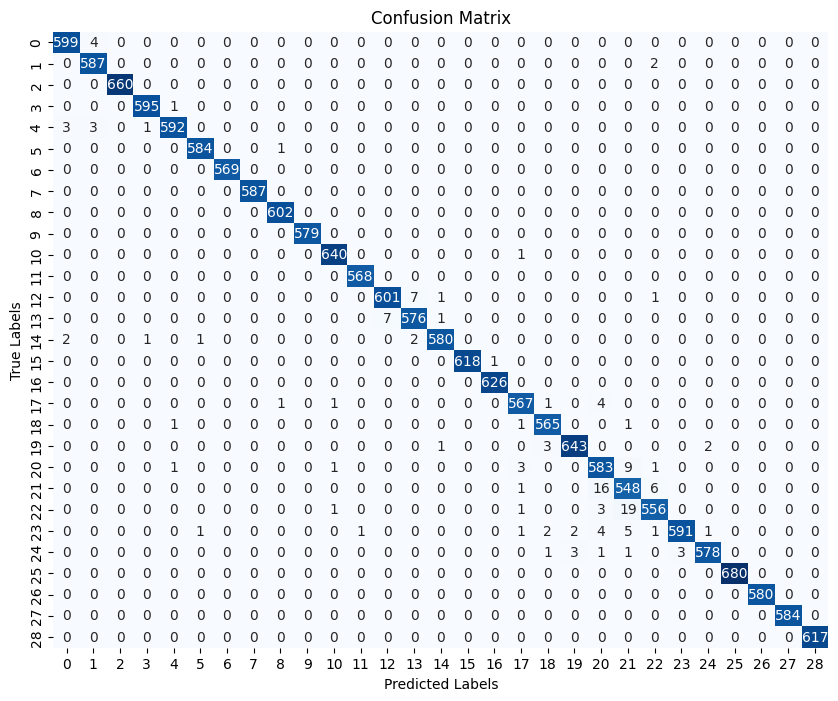

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

# Set the labels, title and show the plot
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [7]:

import joblib  # Import joblib for model persistence# Save the trained model
model_filename = 'svm_asl_model.joblib'
joblib.dump(model, model_filename)
print(f'Model saved to {model_filename}')

Model saved to svm_asl_model.joblib


In [13]:
import os
import numpy as np
from skimage import io, color, transform, feature
from joblib import load

# Function to preprocess the image and extract HOG features
def preprocess_image(image_path):
    image = io.imread(image_path)  # Read the image
    image = transform.resize(image, (64, 64))  # Resize to 64x64
    image = color.rgb2gray(image)  # Convert to grayscale
    hog_features = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    return hog_features

# Load the trained model
model = load("/kaggle/working/svm_asl_model.joblib")

# Specify the path to the test directory
test_dir = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

# Check if the test directory exists
if os.path.exists(test_dir):
    # Iterate through each file in the test directory
    for image_name in os.listdir(test_dir):
        # Construct the full image path
        image_path = os.path.join(test_dir, image_name)
        
        # Extract the actual label from the image name (before the "_" sign)
        actual_label = image_name.split('_')[0]
        
        # Preprocess the image
        hog_features = preprocess_image(image_path)
        
        # Reshape for the model (1 sample, number of features)
        hog_features = np.array(hog_features).reshape(1, -1)
        
        # Predict the sign language
        prediction = model.predict(hog_features)
        
        # Print the actual label and the prediction
        print(f'Actual: {actual_label}, Prediction: {prediction[0]}')
else:
    print(f"Test directory not found at {test_dir}")


Actual: A, Prediction: A
Actual: E, Prediction: E
Actual: L, Prediction: L
Actual: N, Prediction: N
Actual: S, Prediction: S
Actual: D, Prediction: D
Actual: G, Prediction: G
Actual: I, Prediction: I
Actual: W, Prediction: W
Actual: M, Prediction: M
Actual: nothing, Prediction: nothing
Actual: X, Prediction: X
Actual: H, Prediction: H
Actual: Q, Prediction: Q
Actual: C, Prediction: C
Actual: T, Prediction: T
Actual: P, Prediction: P
Actual: V, Prediction: V
Actual: Y, Prediction: Y
Actual: U, Prediction: U
Actual: space, Prediction: space
Actual: O, Prediction: O
Actual: B, Prediction: B
Actual: R, Prediction: R
Actual: F, Prediction: F
Actual: Z, Prediction: Z
Actual: J, Prediction: J
Actual: K, Prediction: K
